In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import time
from scipy import special as scisp
from scipy.integrate import solve_ivp
from scipy.interpolate import InterpolatedUnivariateSpline,CubicSpline
import scipy.integrate
import scipy.optimize
import multiprocessing
from tqdm import trange
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, NullFormatter
import sys
from pathlib import Path
# add main_directory/ to the import path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from source.SecludedDM import Cosmology, HiggsPortal, BoltzmannSolver, find_mXstar

plt.style.use('/home/gab/Desktop/PyCharm_env/mine.mplstyle')
plt.rcParams["axes.axisbelow"] = False
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")

In [6]:
lams_rs_str=['lam5e-02_r1.5','lam5e-02_r5.0','lam1e-01_r1.5','lam1e-01_r5.0']
lams_rs_vals=np.array([[5e-2,1.5],[5e-2,5],[1e-1,1.5],[1e-1,5]])

In [14]:
def load_relic(fname):
    with open(fname) as f:
        params = dict(s.split('=') for s in f.readline().lstrip('# ').split())
    mXs, mYs, epsXs, epsXs_bbn = np.loadtxt(fname).T
    return {**{k: float(v) for k, v in params.items()},
            'mXs': mXs, 'mYs': mYs, 'epsXs': epsXs, 'epsXs_bbn': epsXs_bbn}
dats=[]
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
for i in range(len(lams_rs_str)):
    dat1 = load_relic("../output/hP/relic_"+str(lams_rs_str[i])+".dat")
    mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
    mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
    epsXs1 = np.concatenate([[1e-1, dat1['epsX_min']],    epsXs1])
    mXs_bbn_dd=np.logspace(np.log10(min([2,min(mXs1)])),np.log10(max(mXs1)),1000)
    bbn_bound=interp1d(mXs1[2:],epsXs_bbn1, kind="linear", fill_value="extrapolate", bounds_error=False)
    epsXs_bbn=bbn_bound(mXs_bbn_dd)
    epsXs_LZ=np.zeros(len(mXs_bbn_dd))
    epsXs_nu=np.zeros(len(mXs_bbn_dd))
    for j in trange(len(mXs_bbn_dd)):
        model = HiggsPortal(
            mX=mXs_bbn_dd[j],       
            mY=mXs_bbn_dd[j]/lams_rs_vals[i][1],       
            lam=lams_rs_vals[i][0]
        )
        solver = BoltzmannSolver(cosmo, model)
        try:
            epsXs_LZ[j]= solver.find_epsilon_DD(constraint='LZ',log10eps_range=(-9,0))
            epsXs_nu[j] = solver.find_epsilon_DD(constraint='nufloor_Xe',log10eps_range=(-9,0))
        except:
            epsXs_LZ[j]=1
            epsXs_nu[j]=1
            #continue
    Dict={'mXs':mXs1,'epsXs':epsXs1,'mXs_bbn_dd':mXs_bbn_dd,'epsXs_bbn':epsXs_bbn,'epsXs_LZ':epsXs_LZ,'epsXs_nu':epsXs_nu}
    dats.append(Dict)
    del Dict

 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...


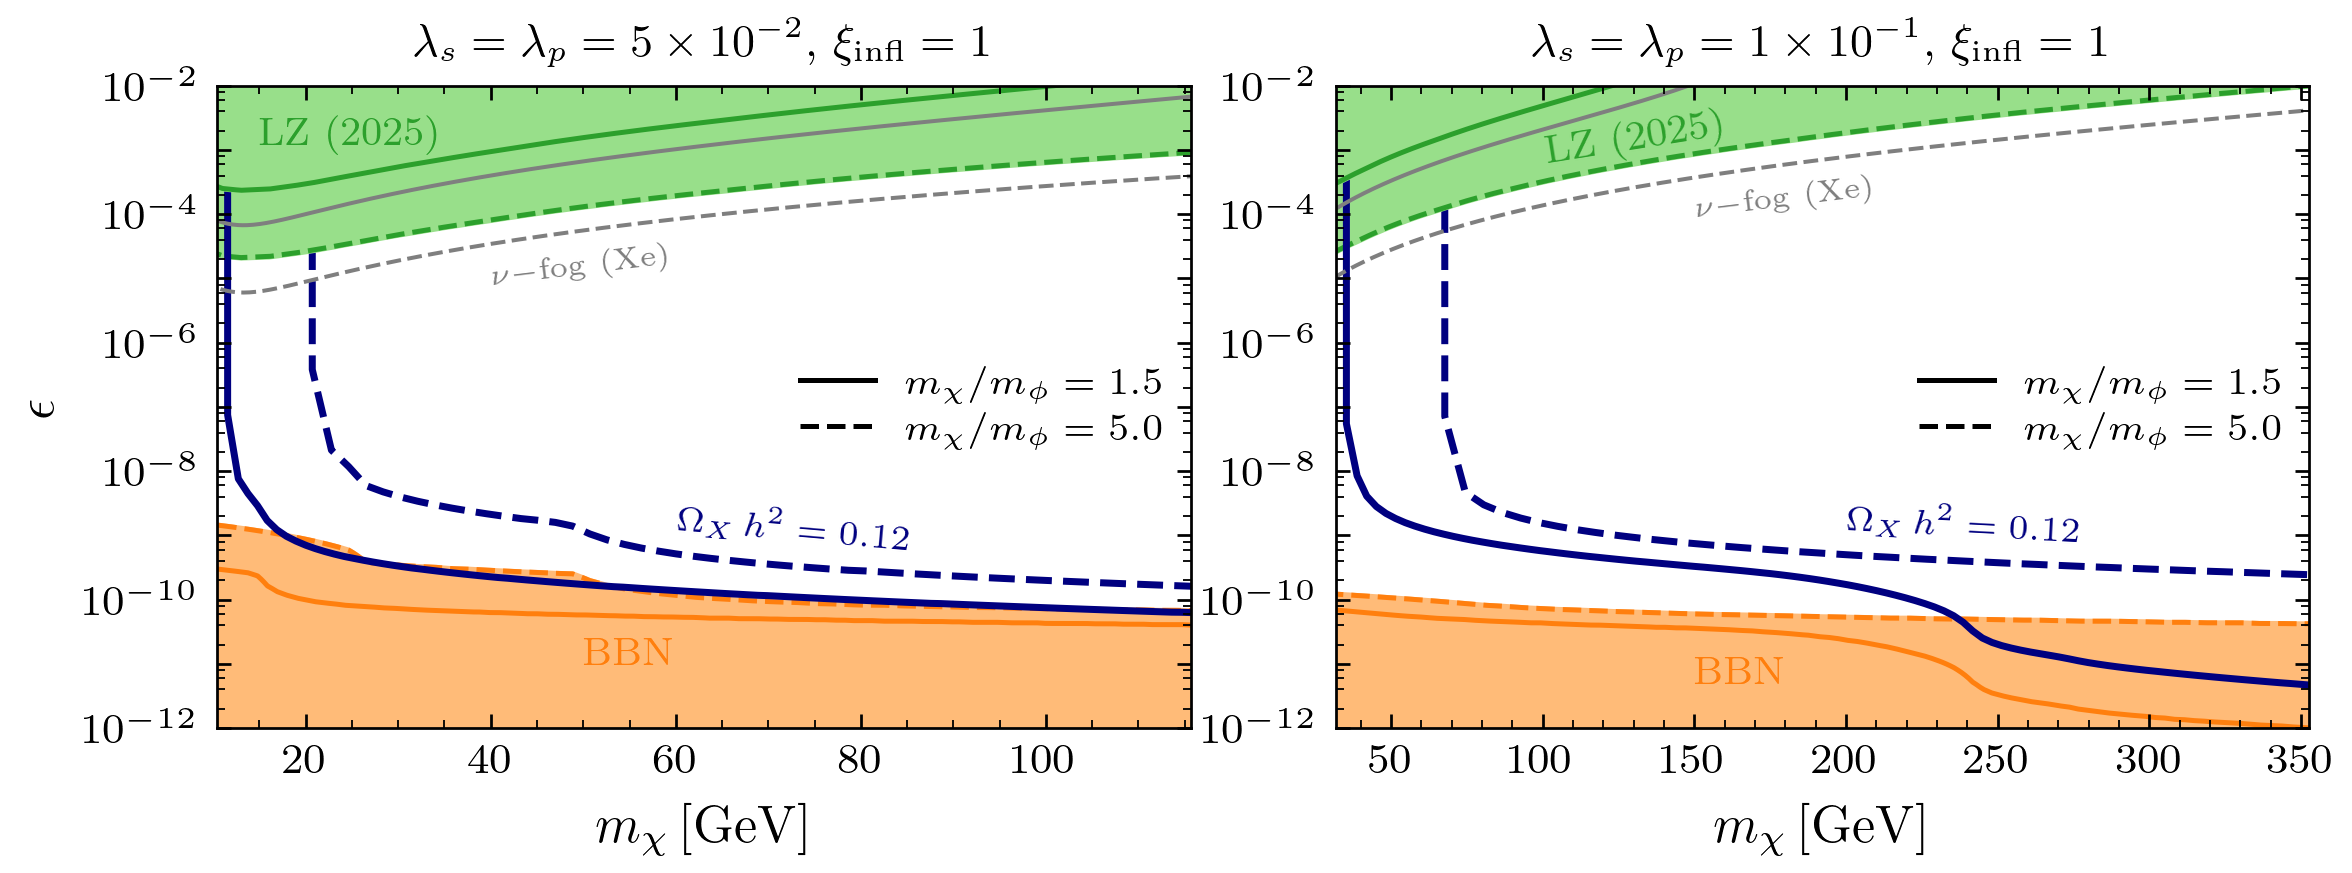

In [38]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(20,17,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:8])
ax2 = fig1.add_subplot(gs1[:,9:])
lss=['-','--']
ZOs=[[-0.8,-.7],[-1,-0.9]]

for j in range(2):
    ax1.plot(dats[j]['mXs'],dats[j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax1.fill_between(dats[j]['mXs_bbn_dd'],0, dats[j]['epsXs_bbn'],lw=1,color=cs[3],alpha=1,zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_bbn'],lw=1,color=cs[2],ls=lss[j],zorder=ZOs[j][1])
    ax1.fill_between(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_LZ'],1,lw=1,color=cs[5],alpha=1,zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_LZ'],lw=1,color=cs[4],ls=lss[j],zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
    ax2.plot(dats[2+j]['mXs'],dats[2+j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax2.fill_between(dats[2+j]['mXs_bbn_dd'],0, dats[2+j]['epsXs_bbn'],lw=1,color=cs[3],alpha=1,zorder=ZOs[j][1])
    ax2.plot(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_bbn'],lw=1,color=cs[2],ls=lss[j],zorder=ZOs[j][1])
    ax2.fill_between(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_LZ'],1,lw=1,color=cs[5],alpha=1,zorder=ZOs[j][1])
    ax2.plot(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_LZ'],lw=1,color=cs[4],ls=lss[j],zorder=ZOs[j][1])
    ax2.plot(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
ax1.set_ylabel("$\epsilon$")
axs=[ax1,ax2]
for ax in axs:
    ax.set_yscale("log")
    ax.set_ylim(1e-12,1e-2)
    ax.set_yticks([1e-12,1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2])
    ax.set_yticklabels(['$10^{-12}$','','$10^{-10}$','','$10^{-8}$','','$10^{-6}$','','$10^{-4}$','','$10^{-2}$'])
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.plot(np.NaN,np.NaN,ls='-',lw=1,c='k',label='$m_\chi/m_{\phi}=1.5$')
    ax.plot(np.NaN,np.NaN,ls='--',lw=1,c='k',label='$m_\chi/m_{\phi}=5.0$')
    ax.legend()
    ax.set_xlabel(r"$m_\chi\,[{\rm GeV}]$")
ax1.set_title(r'$\lambda_s=\lambda_p=5\times 10^{-2},\,\xi_{\rm infl}=1$',fontsize=9)
ax2.set_title(r'$\lambda_s=\lambda_p=1\times 10^{-1},\,\xi_{\rm infl}=1$',fontsize=9)
ax1.set_xlim(np.min(dats[0]['mXs'])*0.9,np.max(dats[0]['mXs']))
ax2.set_xlim(np.min(dats[2]['mXs'])*0.9,np.max(dats[2]['mXs']))
ax1.text(50,1e-11,r"BBN",color=cs[2],fontsize=8)
ax2.text(150,5e-12,r"BBN",color=cs[2],fontsize=8)
ax1.text(15,1.2e-3,r"LZ (2025)",color=cs[4], fontsize=8)
ax2.text(100,6.5e-4,r"LZ (2025)",color=cs[4], fontsize=8,rotation=9)
ax1.text(40,8e-6,r"$\nu-$fog (Xe)",color='tab:gray', fontsize=6, rotation=7)
ax1.text(60,6e-10,r"$\Omega_X\,h^2=0.12$",color='navy', fontsize=7, rotation=-5)
ax2.text(150,9e-5,r"$\nu-$fog (Xe)",color='tab:gray', fontsize=6, rotation=7)
ax2.text(200,8e-10,r"$\Omega_X\,h^2=0.12$",color='navy', fontsize=7, rotation=-3)
plt.savefig("../figs/hP_lam5e-2_1e-1_r1.5_5.png")
plt.savefig("../figs/hP_lam5e-2_1e-1_r1.5_5.pdf")
plt.show()
plt.close()

No handles with labels found to put in legend.


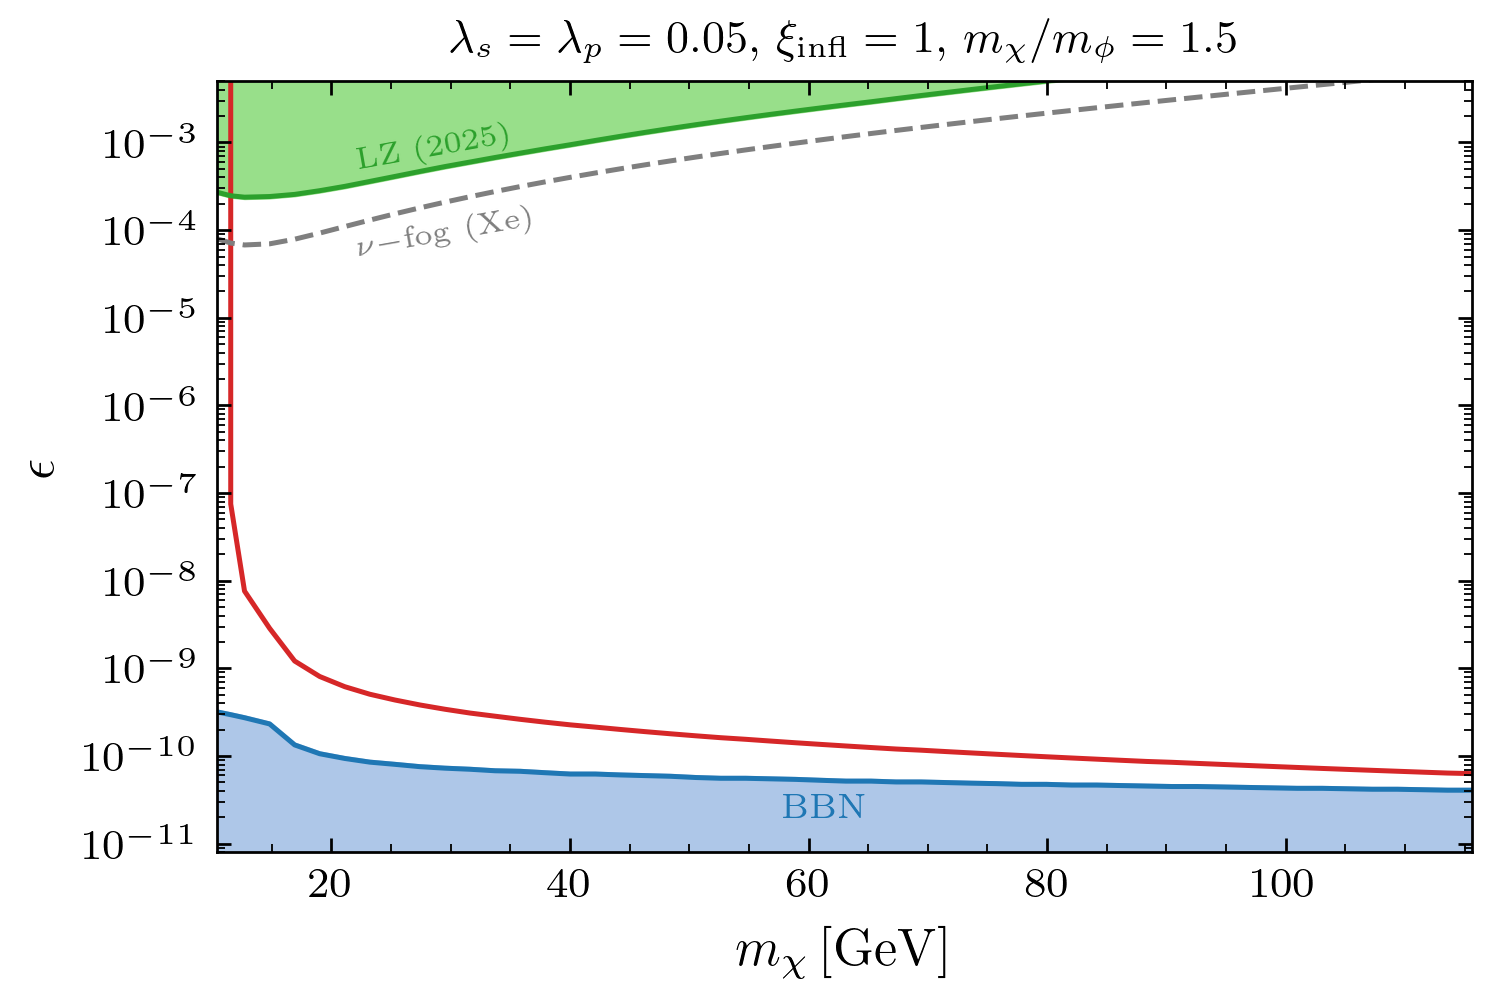

In [22]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
plt.plot(mXs1,epsXs1,lw=1,c=cs[6])
plt.fill_between(mXs_bbn,0, bbn_bound(mXs_bbn),lw=1,color=cs[1],alpha=1)
plt.plot(mXs_bbn,bbn_bound(mXs_bbn),lw=1,color=cs[0],ls='-')
plt.fill_between(mXs_bbn,epsXs_LZ,1,lw=1,color=cs[5],alpha=1)
plt.plot(mXs_bbn,epsXs_LZ,lw=1,color=cs[4],alpha=1)
plt.plot(mXs_bbn,epsXs_nu,lw=1,c='tab:gray',ls='--')
plt.legend()
plt.yscale("log")
plt.ylabel("$\epsilon$")
plt.ylim(8e-12,5e-3)
plt.title(r'$\lambda_s=\lambda_p=0.05,\,\xi_{\rm infl}=1,\,m_\chi/m_{\phi}=1.5$',fontsize=9)
plt.xlim(np.min(mXs1*(1-1e-1)),np.max(mXs1))
plt.text(dat1['mXstar']*5,2e-11,r"BBN",color=cs[0],fontsize=7)
plt.text(22,5e-4,r"LZ (2025)",color=cs[4], fontsize=6, rotation=10)
plt.text(22,5e-5,r"$\nu-$fog (Xe)",color='tab:gray', fontsize=6, rotation=10)
plt.yticks([1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3])
plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3, 0.4, 0.5,0.6, 0.7,0.8,0.9], numticks=200))
plt.gca().yaxis.set_minor_formatter(NullFormatter())
plt.xlabel(r"$m_\chi\,[{\rm GeV}]$")
plt.savefig("../figs/hP_lam5e-2_xiInf1_r1.5.png")
plt.savefig("../figs/hP_lam5e-2_xiInf1_r1.5.pdf")
plt.show()
plt.close()

In [31]:
lam = .1
r = 3
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
factory = lambda mX, mY: HiggsPortal(mX=mX, mY=mY, lam=lam)
res = find_mXstar(cosmo, factory, r=r, verbose=True,verbose_solver=True)
print(f"\nmXstar = {res['mXstar']:.4e} GeV")
print(f"epsX_min = {res['epsX_min']:.4e}")

find_mXstar  (r=3.00)
  mX_est = 1.89e+02 GeV  bracket = [1.89e+01, 9.46e+02]
------------------------------------------------------------
Boltzmann Solver -- QSSA Three-Phase
  mX = 1.89e+01 GeV, mY = 6.31e+00 GeV, r = 3.00
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_can < 1e+00
  Convergence: dlnxi_NR, thr=0.01
------------------------------------------------------------


Evolving:  19%|██████████████████▊                                                                              | 25/129 [00:01<00:03, 27.16it/s]


  -> Phase 1.5 (QSSA) at x = 8.57 (Gamma_ann = 4.8e+09)


Evolving:  51%|█████████████████████████████████████████████████▋                                               | 66/129 [00:02<00:01, 37.77it/s]


  -> Phase 2 (full) at x = 48.45 (Gamma_can=9.7e-01, muX=0.00)


...


  -> Phase 1.5 (QSSA) at x = 4.78 (Gamma_ann = 4.8e+09)


Evolving:  44%|██████████████████████████████████████████▊                                                      | 57/129 [00:02<00:01, 36.34it/s]


  -> Phase 2 (full) at x = 41.46 (Gamma_can=9.0e-01, muX=0.00)


Evolving:  89%|███████████████████████████████████████████████████▋      | 115/129 [00:04<00:00, 24.26it/s, ph=2, x=999, muX=9084.5, dev=2.0e-03]



  Converged (2, dlnxi_NR) at x = 999.0
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 4.78
  x_switch (QSSA -> full): 41.46
  x_FO (muX > 0.05): 41.8
  Converged: True at x = 999.0
  YX_relic = 1.567096e-11
  => epsX_min = 5.7964e-08  (dS/S < 0.001)  SRatio_plateau = 2.4888

mXstar = 6.9515e+01 GeV
epsX_min = 5.7964e-08


In [33]:
mXs=np.linspace(res['mXstar']*(1+1e-1),5*res['mXstar'],50)
mYs=mXs/r
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
t_start=time.time()
for i in trange(len(mXs)):
    model = HiggsPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        lam=lam,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_3phase(return_bg_ICs=True, verbose=False, cannibal_switch_full=1,
                                                 convergence_threshold=1e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    #print(epsXs[i],mXs[i])
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-15,-9),root_rtol=1e-3)
    #print(epsXs[i],epsXs_bbn[i])
    #print("t=",time.time()-t_start)
    #break
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"lam={lam:.1e}  r={r}  mXstar={res['mXstar']:.6e}  "
          f"epsX_min={res['epsX_min']:.6e}  SRatio_plateau={res['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/hP/relic_lam{lam:.0e}_r{r}.dat", data, header=header, fmt='%.8e')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [06:17<00:00,  7.54s/it]


In [43]:
dat1 = load_relic("../output/hP/relic_lam1e-01_r3.dat")
mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
epsXs1 = np.concatenate([[1e-4, dat1['epsX_min']],    epsXs1])
bbn_bound=interp1d(mXs1[2:],epsXs_bbn1, kind="linear", fill_value="extrapolate", bounds_error=False)
mXs_bbn=np.concatenate([[0.9*mXs1[0]],mXs1])

No handles with labels found to put in legend.


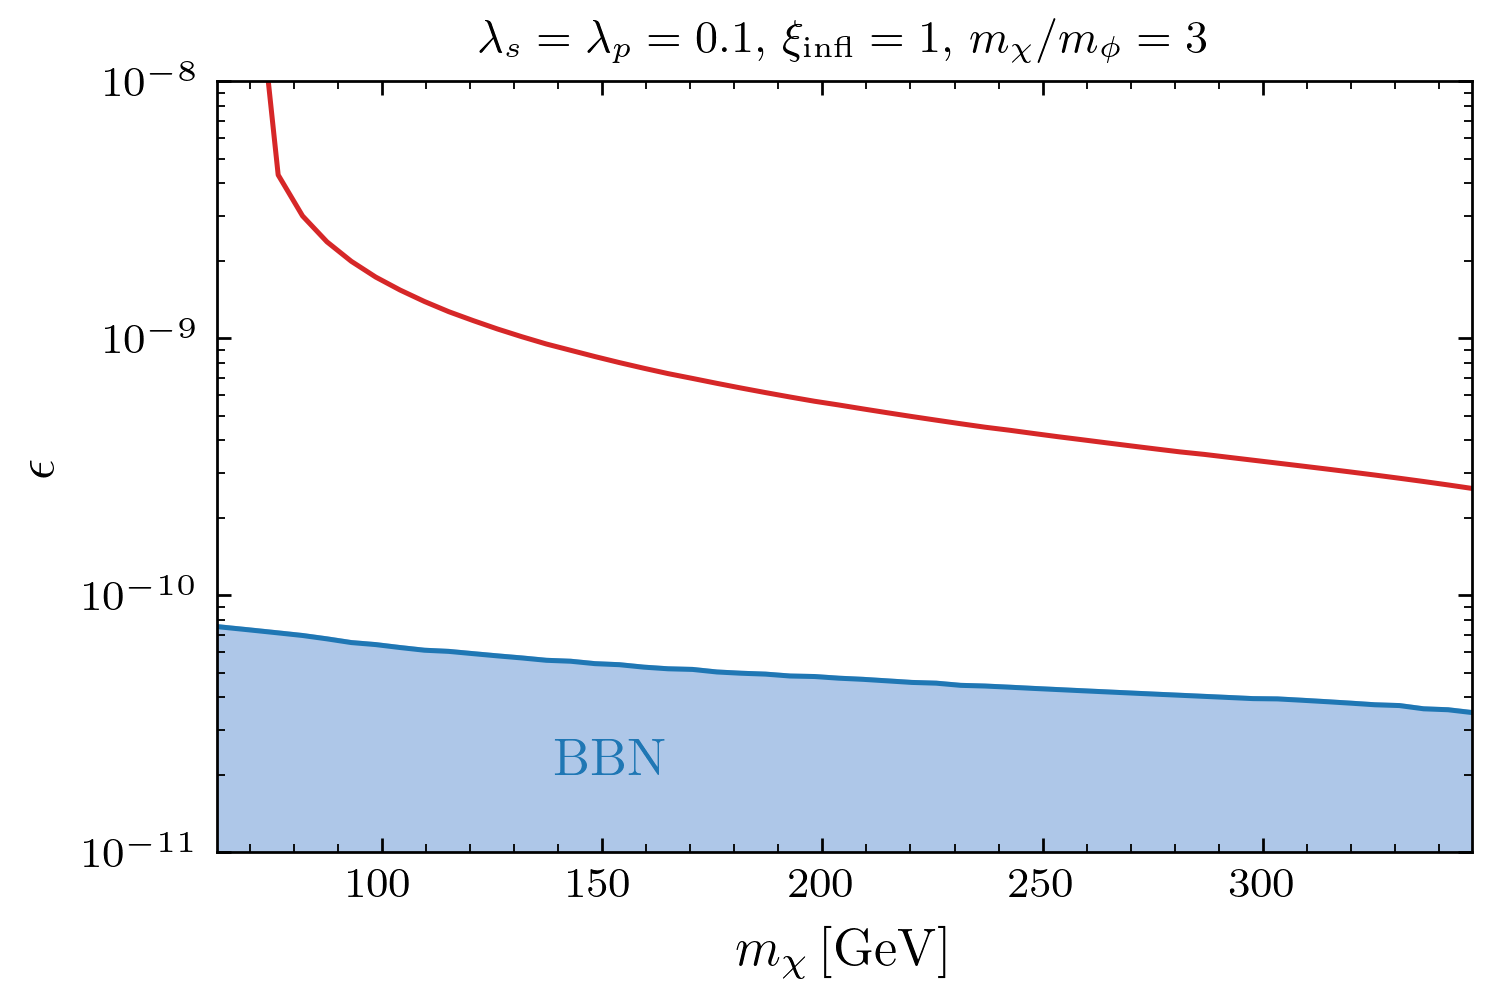

In [45]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
plt.plot(mXs1,epsXs1,lw=1,c=cs[6])
plt.fill_between(mXs_bbn,0, bbn_bound(mXs_bbn),lw=1,color=cs[1],alpha=1)
plt.plot(mXs_bbn,bbn_bound(mXs_bbn),lw=1,color=cs[0],ls='-')
plt.legend()
plt.yscale("log")
plt.ylabel("$\epsilon$")
plt.ylim(1e-11,1e-8)
plt.title(r'$\lambda_s=\lambda_p=0.1,\,\xi_{\rm infl}=1,\,m_\chi/m_{\phi}=3$',fontsize=9)
plt.xlim(np.min(mXs1*(1-1e-1)),np.max(mXs1))
plt.text(dat1['mXstar']*2,2e-11,r"BBN",color=cs[0])
plt.xlabel(r"$m_\chi\,[{\rm GeV}]$")
plt.savefig("../figs/hP_lam1e-1_xiInf1_r3.png")
plt.savefig("../figs/hP_lam1e-1_xiInf1_r3.pdf")
plt.show()
plt.close()

In [34]:
lam = .25
r = 10
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
factory = lambda mX, mY: HiggsPortal(mX=mX, mY=mY, lam=lam)
res = find_mXstar(cosmo, factory, r=r, verbose=True,verbose_solver=True)
print(f"\nmXstar = {res['mXstar']:.4e} GeV")
print(f"epsX_min = {res['epsX_min']:.4e}")

find_mXstar  (r=10.00)
  mX_est = 1.15e+03 GeV  bracket = [1.15e+02, 5.77e+03]
------------------------------------------------------------
Boltzmann Solver -- QSSA Three-Phase
  mX = 1.15e+02 GeV, mY = 1.15e+01 GeV, r = 10.00
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_can < 1e+00
  Convergence: dlnxi_NR, thr=0.01
------------------------------------------------------------


Evolving:  21%|████████████████████▎                                                                            | 27/129 [00:01<00:03, 32.77it/s]


  -> Phase 1.5 (QSSA) at x = 12.49 (Gamma_ann = 3.5e+09)


Evolving:  88%|█████████████████████████████████████████████████▉       | 113/129 [00:04<00:00, 103.15it/s, ph=1.5, x=999, muX=73.8, dev=2.2e+00]


  -> Phase 2 (full) at x = 999.00 (Gamma_can=1.4e-02, muX=73.83)


...


  -> Phase 1.5 (QSSA) at x = 8.10 (Gamma_ann = 4.9e+09)


Evolving:  88%|███████████████████████████████████████████████████▎      | 114/129 [00:03<00:00, 77.46it/s, ph=1.5, x=500, muX=46.4, dev=1.7e+00]


  -> Phase 2 (full) at x = 499.50 (Gamma_can=5.6e-01, muX=46.41)


Evolving:  91%|███████████████████████████████████████████████████▏    | 118/129 [00:15<00:01,  7.59it/s, ph=2, x=9990, muX=36381.8, dev=1.8e-03]



  Converged (2, dlnxi_NR) at x = 9990.0
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 8.10
  x_switch (QSSA -> full): 499.50
  x_FO (muX > 0.05): 46.5
  Converged: True at x = 9990.0
  YX_relic = 2.295698e-12
  => epsX_min = 8.0084e-08  (dS/S < 0.001)  SRatio_plateau = 3.9030

mXstar = 7.4531e+02 GeV
epsX_min = 8.0084e-08


In [42]:
mXs=np.linspace(res['mXstar']*(1+1e-1),1e5,70)
mYs=mXs/r
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
for i in trange(len(mXs)):
    model = HiggsPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        lam=lam,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_3phase(return_bg_ICs=True, verbose=False, cannibal_switch_full=1,
                                                 convergence_threshold=1e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-20,-9),root_rtol=1e-3)
    #print(epsXs[i],epsXs_bbn[i])
    #print("t=",time.time()-t_start)
    #break
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"lam={lam:.1e}  r={r}  mXstar={res['mXstar']:.6e}  "
          f"epsX_min={res['epsX_min']:.6e}  SRatio_plateau={res['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/hP/relic_lam{lam:.0e}_r{r}.dat", data, header=header, fmt='%.8e')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [14:47<00:00, 12.68s/it]


In [46]:
dat1 = load_relic("../output/hP/relic_lam2e-01_r10.dat")
mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
epsXs1 = np.concatenate([[1e-4, dat1['epsX_min']],    epsXs1])
bbn_bound=interp1d(mXs1[2:],epsXs_bbn1, kind="linear", fill_value="extrapolate", bounds_error=False)
mXs_bbn=np.concatenate([[0.9*mXs1[0]],mXs1])

No handles with labels found to put in legend.


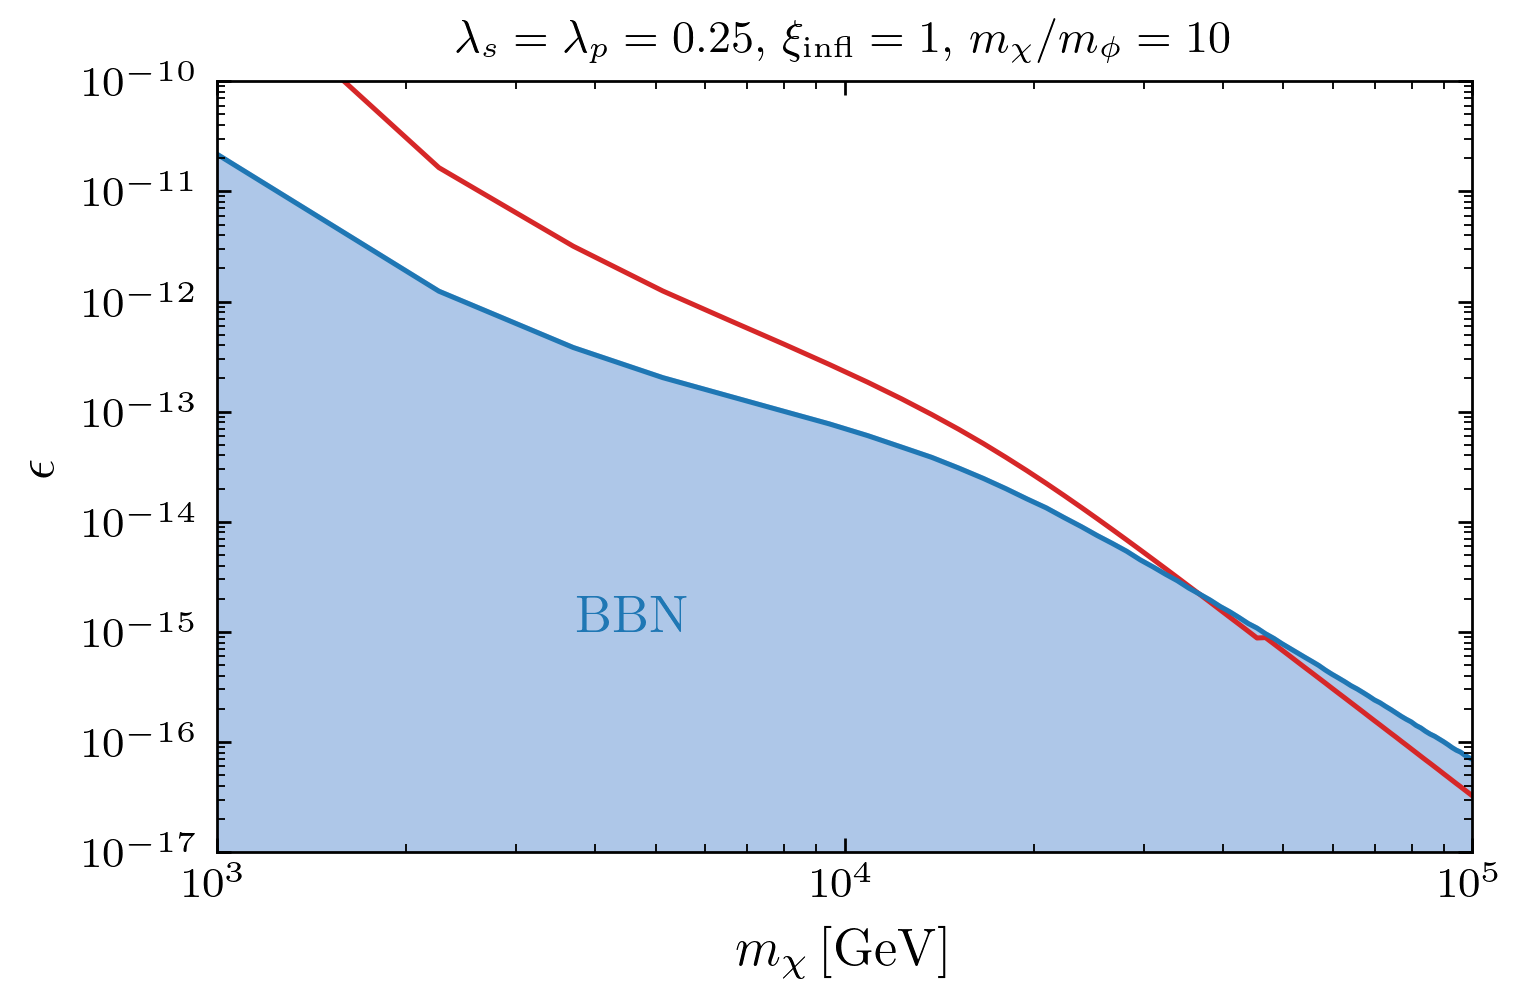

In [52]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
plt.plot(mXs1,epsXs1,lw=1,c=cs[6])
plt.fill_between(mXs_bbn,0, bbn_bound(mXs_bbn),lw=1,color=cs[1],alpha=1)
plt.plot(mXs_bbn,bbn_bound(mXs_bbn),lw=1,color=cs[0],ls='-')
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.ylabel("$\epsilon$")
plt.ylim(1e-17,1e-10)
plt.title(r'$\lambda_s=\lambda_p=0.25,\,\xi_{\rm infl}=1,\,m_\chi/m_{\phi}=10$',fontsize=9)
plt.xlim(1e3,1e5)
plt.text(dat1['mXstar']*5,1e-15,r"BBN",color=cs[0])
plt.xlabel(r"$m_\chi\,[{\rm GeV}]$")
plt.savefig("../figs/hP_lam2.5e-1_xiInf1_r10.png")
plt.savefig("../figs/hP_lam2.5e-1_xiInf1_r10.pdf")
plt.show()
plt.close()